## Check hos WT amplitude depends on scale (frequency)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

path.append('../../signals/')
import signals as sg

import matlab.engine

In [35]:
eng = matlab.engine.start_matlab()

In [350]:
T = 5000 # s
dt = 0.1 # s
Fs = 1/dt
nt = int(T/dt)
fsignals = np.array([0.5, 2])

t = np.arange(nt)*dt
x = np.array([sg.cosine(T, fsig, 
               sampling_frequency=Fs, 
               phase=np.random.uniform(-np.pi, np.pi))[1] for fsig in fsignals])
x = x.sum(axis=0) # sum of cosines

y = np.random.randn(nt) # noise

z = x + y # noisy sum of cosines

In [351]:
cwt_x = wf.matlab_cwt(eng, x, Fs, voices_per_octave=24)
cwt_y = wf.matlab_cwt(eng, y, Fs, voices_per_octave=24)
cwt_z = wf.matlab_cwt(eng, z, Fs, voices_per_octave=24)

## Time-averaged |W| spectrum of noisy sum of cosines

## Peaks have approximately the same height due to $L^1$-normalization of wavelets implemented in MATLAB ($L^1$-normalization makes the scaled wavelets keep constant $L^1$-norm, i.e., amplitude).

## Background increases as $\sqrt{f}$ due to white noise.

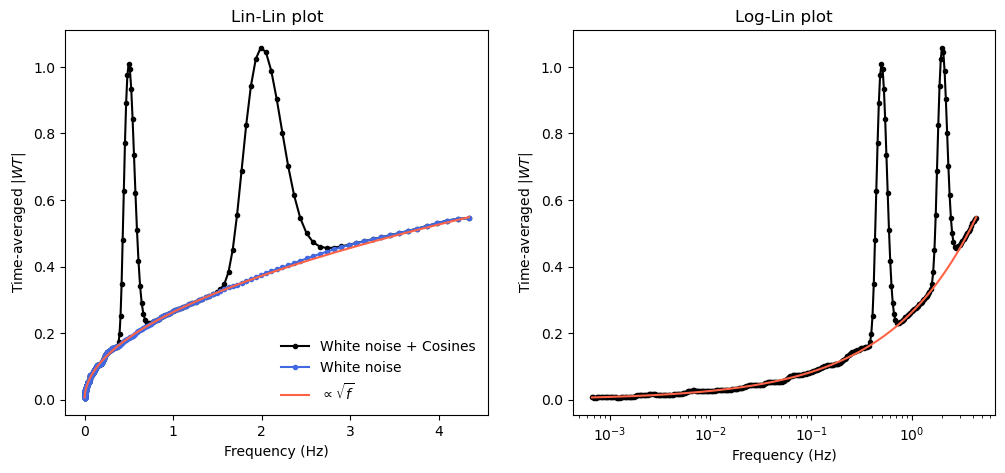

In [275]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(12,5))

k = 3.8

ax.plot(cwt_z.f, cwt_z.wt_amp.mean('t'), color='k', marker='.', label='White noise + Cosines')
ax.plot(cwt_y.f, cwt_y.wt_amp.mean('t'), color='royalblue', marker='.', label='White noise')
ax.plot(cwt_z.f, np.sqrt(cwt_z.f)/k, color='tomato', label=r'$\propto\sqrt{f}$')
ax.legend(frameon=False)
ax.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|$', title='Lin-Lin plot')

ax1.plot(cwt_z.f, cwt_z.wt_amp.mean('t'), marker='.', color='k',)
# ax1.plot(cwt_y.f, cwt_y.wt_amp.mean('t'), color='royalblue', marker='.', label='White noise')
ax1.plot(cwt_z.f, np.sqrt(cwt_z.f)/k, color='tomato', label=r'$\frac{\sqrt{f}}{2.7}$, coming from white noise')
ax1.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|$', title='Log-Lin plot')
ax1.set_xscale('log')

## Time-averaged $|W|^2/f$ spectrum of noisy sum of cosines

## Dividing $|W|$ with $\sqrt{f}$ converts normalization to $L^2$ (up to constant coefficient?). Peaks corresponding to cosines with identical oscillation amplitudes should have approximately the same area under the spectral peaks of $|W|^2/f$.

## $|W|^2/f$ has flat background as $|W|^2/f$ of white noise is flat and proportional to $\sigma^2 ||\psi||^2_2$, where $\sigma^2$ is the noise variance and $\psi$ is the wavelet.

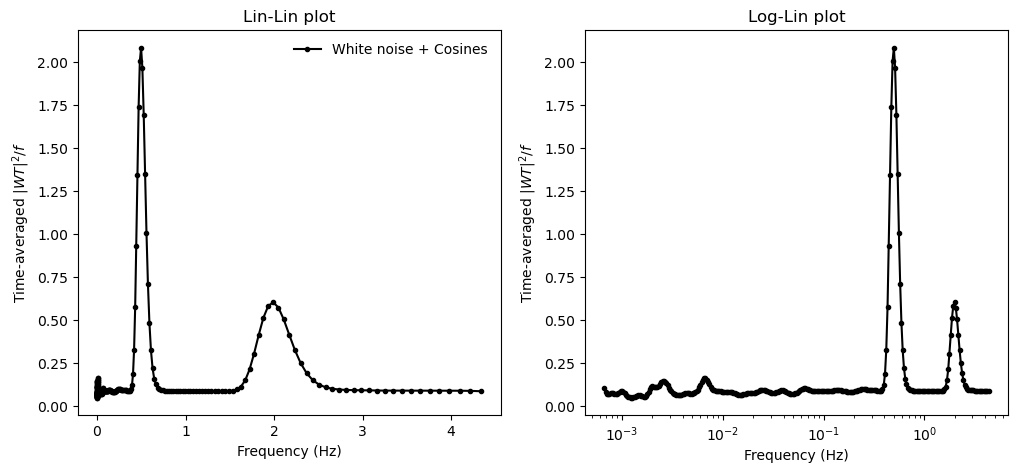

In [283]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(12,5))

ax.plot(cwt_z.f, (cwt_z.wt_amp**2).mean('t')/cwt_z.f, color='k', marker='.', label='White noise + Cosines')
ax.legend(frameon=False)
ax.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|^2/f$', title='Lin-Lin plot')

ax1.plot(cwt_z.f, (cwt_z.wt_amp**2).mean('t')/cwt_z.f, marker='.', color='k',)
ax1.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|^2/f$', title='Log-Lin plot')
ax1.set_xscale('log')

## Time-averaged |W| spectrum of noiseless sum of cosines 

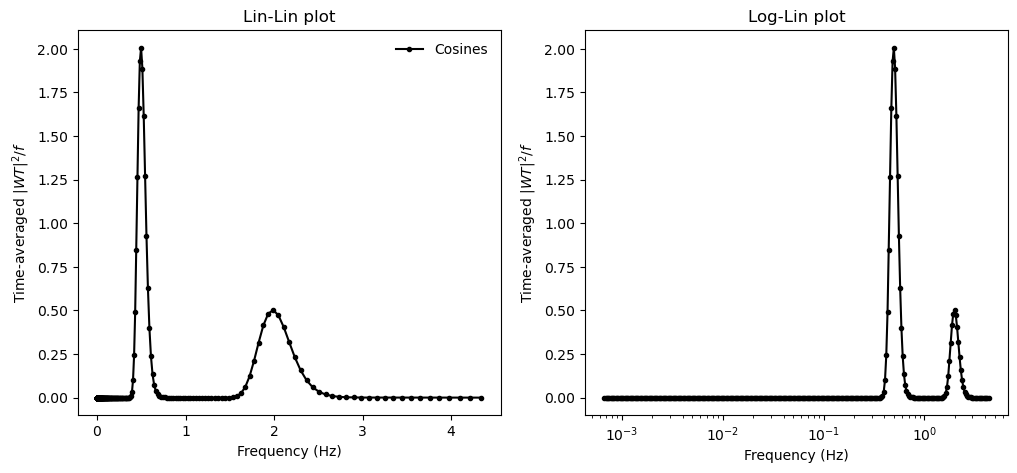

In [282]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(12,5))

ax.plot(cwt_x.f, (cwt_x.wt_amp**2).mean('t')/cwt_z.f, color='k', marker='.', label='Cosines')
ax.legend(frameon=False)
ax.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|^2/f$', title='Lin-Lin plot')

ax1.plot(cwt_x.f, (cwt_x.wt_amp**2).mean('t')/cwt_z.f, marker='.', color='k',)
ax1.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|WT|^2/f$', title='Log-Lin plot')
ax1.set_xscale('log')

# Integrate CWT computed from noiseless cosines along frequency different ways

### Select integration inter

In [284]:
amp = cwt_x.wt_amp.mean('t')/np.sqrt(cwt_z.f)
amp = amp[::-1] # sort in asscending frequency order

In [310]:
peak_bands = [
    slice(0.25, 1.2),
    slice(1.22, 4.3),
]

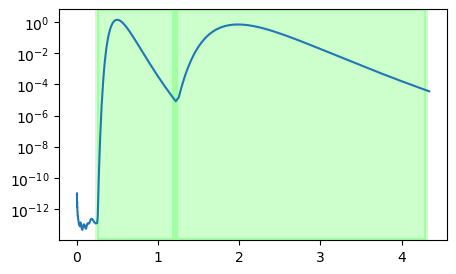

In [311]:
f, ax = plt.subplots(figsize=(5,3))
ax.semilogy(amp.f, amp)
for b in peak_bands:
    ax.axvspan(b.start, b.stop, color='lime', alpha=0.2, lw=3)

## 1. Integrate |W|/$\sqrt{f}$

In [312]:
amp_integral = amp.integrate('f').item()

In [313]:
peak_areas = []
for b in peak_bands:
    val = amp.sel(f=b).integrate('f')
    peak_areas.append(val.item())

In [314]:
peak_areas

[0.23525103457427302, 0.4704884517977883]

In [316]:
sum(peak_areas), amp_integral

(0.7057394863720613, 0.7057463827049598)

---

## 2. Integrate |W|, divide by frequency band width 

In [317]:
amp = cwt_x.wt_amp.mean('t')
amp = amp[::-1] # sort in asscending frequency order

In [318]:
amp_integral = ( amp.integrate('f') / (amp.f.max() - amp.f.min()) ).item()

In [319]:
peak_areas = []
for b in peak_bands:
    val = amp.sel(f=b).integrate('f') / (b.stop - b.start)
    peak_areas.append(val.item())

In [320]:
peak_areas

[0.17858592396995818, 0.22032413919364177]

#### integrals have different value, whith doesn't make much sense since all sines have the same amplitude=1

In [321]:
sum(peak_areas), amp_integral

(0.39891006316359995, 0.1954275760389773)

Obviously different since the summed integrals have different weights (freq band widths)

## 3. Integrate $|W|^2/f$

In [330]:
amp = (cwt_x.wt_amp**2).mean('t')/cwt_z.f # *cwt_z.scale
amp = amp[::-1] # sort in asscending frequency order

In [323]:
amp_integral = amp.integrate('f').item()

In [324]:
peak_areas = []
for b in peak_bands:
    val = amp.sel(f=b).integrate('f')
    peak_areas.append(val.item())

In [325]:
peak_areas

[0.23028917155833376, 0.2302891710679924]

In [326]:
sum(peak_areas), amp_integral

(0.46057834262632613, 0.4605783429570099)

Equal, makes sense...

The integrals over the two different bands are also equal (almost because the spectral peaks don't separate clearly: they overlap at teh level 1e-6, which is neglegible (see above)), which makes sense as we've integrated wavelet energy with L2 normalization.

# What happens if we add noise?

# Integrate CWT computed from NOISY cosines along frequency different ways

## Integrate $|W|^2/f$

In [352]:
amp2 = (cwt_z.wt_amp**2).mean('t')/cwt_z.f # *cwt_z.scale
amp2 = amp2[::-1] # sort in asscending frequency order

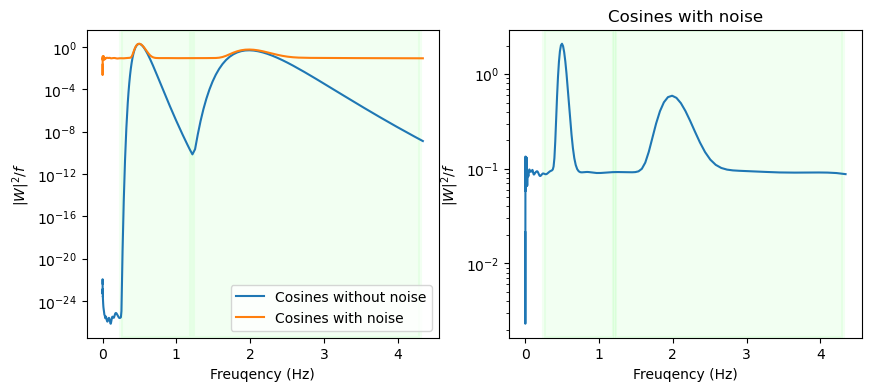

In [362]:
f, (ax,ax1) = plt.subplots(1,2, figsize=(10,4), sharey=False)
ax.semilogy(amp.f, amp, label='Cosines without noise')
ax1.semilogy(amp2.f, amp2)
ax.semilogy(amp2.f, amp2, label='Cosines with noise')
ax.legend()

ax.set(title='',
       ylabel='$|W|^2/f$',
       xlabel='Freuqency (Hz)'
      )
ax1.set(title='Cosines with noise',
       ylabel='$|W|^2/f$',
       xlabel='Freuqency (Hz)'
      )

for axi in (ax,ax1):
    for b in peak_bands:
        axi.axvspan(b.start, b.stop, color='lime', alpha=0.05, lw=3)

In [358]:
peak_areas = []
for b in peak_bands:
    val = amp2.sel(f=b).integrate('f')
    peak_areas.append(val.item())

In [359]:
peak_areas

[0.314853216740657, 0.5010482642110856]

### Now the integral of the peak at the higher frequency is higher because it integrates not only the peak, but also the noise "floor", and over a wider frequency interval than for the peak at lower frequency

### We want a measure representing signal's power in a given band, which is not contaminated by the noise floor. To do that, we subtract from $|W|^2/f$ it's mean value estimated over entire time and frequency band containing no TGF/heartrate/respiration. Then we integrate that difference

In [384]:
band_noise = slice(4, 4.3)
mean_noise = amp2.sel(f=band_noise).mean('f')

amp2_denoise = amp2 - mean_noise

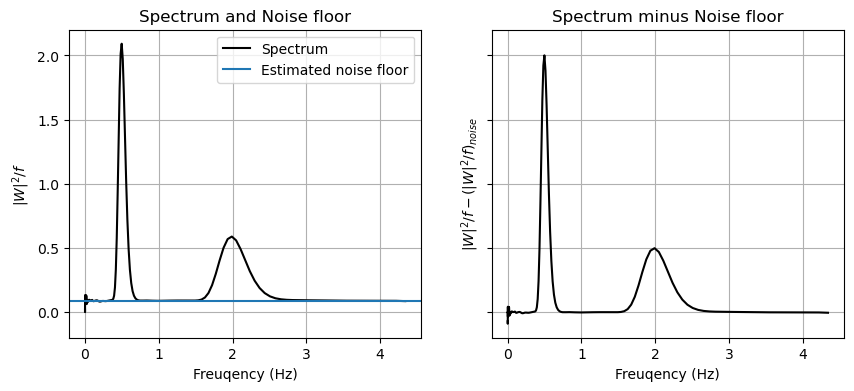

In [386]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(10,4), sharey=True)

ax.plot(amp2.f, amp2, color='k', label='Spectrum')
ax.axhline(mean_noise, label='Estimated noise floor')
ax.legend()
ax.set(title='Spectrum and Noise floor',
       ylabel='$|W|^2/f$',
       xlabel='Freuqency (Hz)'
      )

ax1.plot(amp2.f, amp2_denoise, color='k')
ax1.set(title='Spectrum minus Noise floor',
       ylabel='$|W|^2/f - (|W|^2/f)_{noise}$',
       xlabel='Freuqency (Hz)'
      )

for axi in (ax,ax1):
    axi.grid()

In [387]:
amp_integral = amp2_denoise.integrate('f').item()

In [388]:
peak_areas = []
for b in peak_bands:
    val = amp2_denoise.sel(f=b).integrate('f')
    peak_areas.append(val.item())

In [389]:
peak_areas

[0.23087134268821755, 0.23267482971324024]

In [390]:
sum(peak_areas), amp_integral

(0.4635461724014578, 0.4633628679967866)

# If the integral over a band around a cosine freuqency represents (is proportional to) the signal's power in that band, the integral should grow as squared oscillation amplitude. Check this:

In [400]:
amps = np.arange(1, 21, 3)
signals = [sg.cosine(T, 0.02, Fs, amplitude=amp)[1] for amp in amps]

(1000.0, 1400.0)

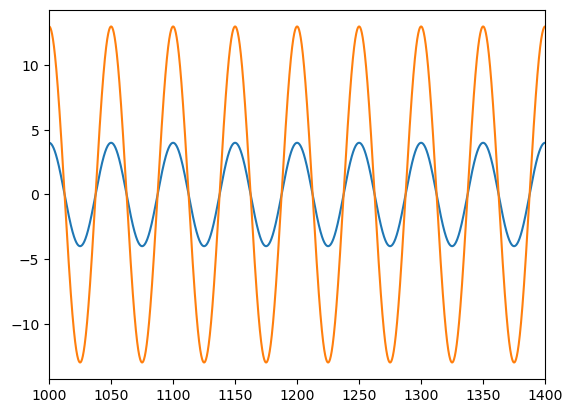

In [405]:
plt.plot(t, signals[1], t, signals[4])
plt.xlim(1000, 1400)

In [460]:
cwts = [wf.matlab_cwt(eng, s, Fs) for s in signals]
cwt_pows = [(r.wt_amp**2).mean('t')/r.f for r in cwts]

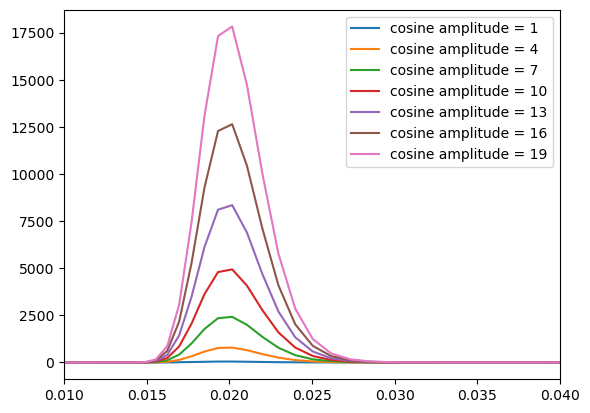

In [461]:
for r, a in zip(cwt_pows, amps):
    plt.plot(r.f, r, label=f"cosine amplitude = {a}")
plt.xlim(0.01, 0.04)
plt.legend()

In [462]:
band_powers = [r[::-1].sel(f=slice(0.01, 0.04)).integrate('f').item() for r in cwt_pows]

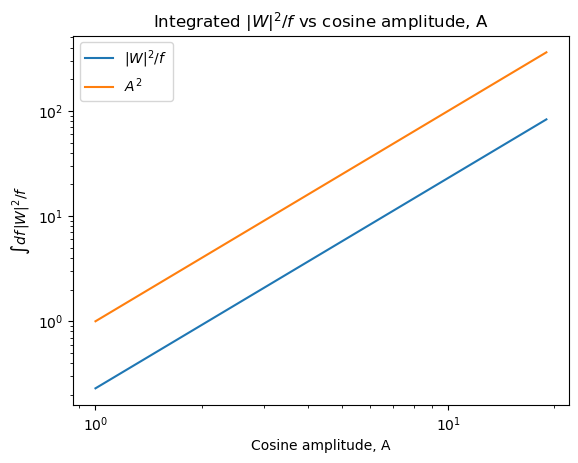

In [463]:
f, ax = plt.subplots()
ax.loglog(amps, band_powers, label='$|W|^2/f$')
ax.loglog(amps, np.array(amps)**2, label='$A^2$')
ax.set(ylabel='$\int df\,|W|^2/f$',
       xlabel='Cosine amplitude, A',
       title='Integrated $|W|^2/f$ vs cosine amplitude, A',
      )
ax.legend()

In [464]:
band_powers

[0.23032917762054972,
 3.6852668419287955,
 11.286129703404704,
 23.032917762053327,
 38.92563101786973,
 58.96426947086073,
 83.14883312101118]

### This (band-)integrated $|W|^2/f$ scales as squared amplitude of oscillation, as power of cosine does. This simply confirms that (band-)integrated $|W|^2/f$ is proportional to signal's power in a frequency band.